# Q1: The Mechanics of Learning - Optimizers, Normalization, and Memory

## Part A: Theoretical Foundations

### 1A.1 Optimizer Dynamics

#### (a) Momentum-based SGD Update:

The standard SGD update is:
$$
w_{t+1} = w_t - \eta \nabla L(w_t)
$$

With momentum, we introduce a velocity term $v_t$:
$$
v_t = \beta v_{t-1} + \nabla L(w_t)
$$
$$
w_{t+1} = w_t - \eta v_t
$$

Here, $\beta \in [0,1)$ is the momentum coefficient.

**Explanation:**

The velocity term acts like a running average of past gradients, allowing the optimizer to build up speed in directions where gradients consistently point the same way. This helps the optimizer move faster across flat or shallow regions of the loss surface (escaping shallow local minima). At the same time, in directions where the gradient oscillates (such as narrow ravines), the averaging effect smooths out these oscillations, leading to more stable and directed updates.

---

#### (b) Why Nesterov Momentum is called “look-ahead”:

Nesterov momentum computes the gradient at a future (look-ahead) position of the parameters, i.e., after applying the current velocity, rather than at the current parameters.

### 1A.2 Adaptive vs. Fixed Learning Rates

#### (a) Why Adam has a warm-start advantage:

Adam maintains exponential moving averages of both the first moment (mean) and second moment (uncentered variance) of the gradients for each parameter. This allows it to adaptively scale the learning rate for each parameter based on past gradient behavior.

In the initial stages of training, when gradients may vary significantly across parameters, Adam can take appropriately sized steps: larger for infrequent or small gradients and smaller for large or noisy gradients. This leads to faster and more stable progress in the first few epochs compared to vanilla SGD, which uses a fixed learning rate for all parameters.

---

#### (b) Why practitioners switch from Adam to SGD:

A commonly observed phenomenon is that Adam tends to converge quickly but may generalize worse than SGD. Switching to SGD with momentum in later stages often improves generalization because SGD biases the optimization toward flatter minima, which are associated with better performance on unseen data.

### 1A.3 Why Batch Normalization

#### (a) Internal Covariate Shift

Each layer doubles the magnitude of its input. After 10 layers, the magnitude grows by a factor:
$$
2^{10} = 1024
$$

This exponential growth leads to exploding activations, where values become extremely large as they propagate through the network. As a result, even small changes in the learning rate can cause unstable updates or divergence. This makes it difficult to choose a single learning rate that works well across all layers.

---

#### (b) Mechanics of BatchNorm

The Batch Normalization transform is:
$$
\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \quad y_i = \gamma \hat{x}_i + \beta
$$

The parameters $\gamma$ and $\beta$ are learnable scaling and shifting terms. They allow the network to adjust the normalized activations to any required distribution.

If we only normalize, the activations are forced to have zero mean and unit variance, which may restrict the model’s ability to represent useful features. $\gamma$ and $\beta$ restore flexibility so the network can learn the optimal scale and shift.

---

#### (c) BatchNorm at Test Time

During inference, mini-batch statistics are not available. Instead, BatchNorm uses running estimates of the mean and variance.

These running statistics are computed during training as exponential moving averages of the batch-wise mean and variance. At test time, these stored values are used for normalization, ensuring consistent behavior regardless of batch size.

### 1A.4 Gradient Accumulation

#### (a) Equivalence to a Larger Batch

Let the loss over a batch of size $B_{\text{large}} = 32$ be:
$$
L = \frac{1}{32} \sum_{i=1}^{32} \ell_i
$$

The gradient is:
$$
\nabla L = \frac{1}{32} \sum_{i=1}^{32} \nabla \ell_i
$$

Now split this into $N = 4$ micro-batches of size $8$. For each micro-batch $k$:
$$
g_k = \frac{1}{8} \sum_{i \in \text{batch } k} \nabla \ell_i
$$

During training, we perform 4 forward–backward passes and accumulate gradients without calling `optimizer.step()`. The accumulated gradient becomes:
$$
g = \sum_{k=1}^{4} g_k
= \sum_{k=1}^{4} \left( \frac{1}{8} \sum_{i \in k} \nabla \ell_i \right)
= \frac{1}{8} \sum_{i=1}^{32} \nabla \ell_i
$$

If we divide the loss by $N=4$ during each step (or equivalently scale gradients), we get:
$$
g = \frac{1}{32} \sum_{i=1}^{32} \nabla \ell_i
$$

After accumulating gradients over 4 steps, we call `optimizer.step()` once, which updates the parameters using this final gradient. This is equivalent to performing a single update using a batch of size 32.

---

#### (b) BatchNorm Statistics

No, gradient accumulation does not produce the same BatchNorm statistics as a true batch of size 32.

BatchNorm computes mean and variance during each forward pass using only the current mini-batch. In gradient accumulation, each forward pass processes 8 samples, so the running mean and variance are updated based on these smaller batches.

In contrast, a true batch of 32 would compute statistics over all 32 samples in a single forward pass. Therefore, the running statistics seen by BatchNorm differ, even though the final gradient used in `optimizer.step()` is equivalent.

### 1A.5 Quick Conceptual Questions

#### (a) Bias term with BatchNorm

The bias term in a convolutional layer is redundant when followed by BatchNorm because BatchNorm subtracts the batch mean, which cancels out any constant bias. Additionally, the learnable parameter $\beta$ in BatchNorm already provides a shift, making the bias unnecessary.

---

#### (b) Freezing $\gamma$ and $\beta$

Yes, training still benefits from normalization even if $\gamma$ and $\beta$ are frozen. The normalization step stabilizes the distribution of activations, which improves gradient flow and training stability, although the model loses some flexibility in adjusting the scale and shift.

---

#### (c) Decoupled weight decay in AdamW

In AdamW, weight decay is applied directly to the weights as a separate step, rather than being added to the gradient. This is called "decoupled" because the regularization effect is independent of the adaptive gradient updates, leading to more consistent and effective regularization.

## Part B: Practical Implementation

In [1]:
# Dependencies, Imports and Reproducibility setup

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
# CIFAR-10 Data Loading

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)

val_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=64, shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=64, shuffle=False
)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))

100.0%
/Users/souradeepdas/Desktop/IIIT 2nd sem/smai/assignments/assignment_2/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train size: 50000
Validation size: 10000


In [3]:
# CNN Model Definition (<= 3 Conv Layers)

class SimpleCNN(nn.Module):
    def __init__(self, use_bn=False):
        super().__init__()

        def conv_block(in_c, out_c):
            layers = [nn.Conv2d(in_c, out_c, kernel_size=3, padding=1)]
            if use_bn:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.ReLU())
            layers.append(nn.MaxPool2d(2))
            return nn.Sequential(*layers)

        self.net = nn.Sequential(
            conv_block(3, 32),
            conv_block(32, 64),
            conv_block(64, 128)
        )

        self.fc = nn.Linear(128 * 4 * 4, 10)

    def forward(self, x):
        x = self.net(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

print("Model ready")

Model ready


In [4]:
# Training and Evaluation utilities

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return correct / total

print("Training utilities ready")

Training utilities ready


### 1B.1 Optimizer Face-off (10 pts)

We train the same CNN architecture for 15 epochs using three optimizers:

- Vanilla SGD (η = 0.01)
- SGD with Momentum (η = 0.01, β = 0.9)
- AdamW (η = 0.001)

We compare:
- Training loss
- Validation accuracy

All results are plotted for comparison.

In [5]:
# Optimizer Experiment Function

def run_experiment(optimizer_name):
    model = SimpleCNN().to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=0.01)

    elif optimizer_name == "momentum":
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    elif optimizer_name == "adamw":
        optimizer = optim.AdamW(model.parameters(), lr=0.001)

    train_losses = []
    val_accuracies = []

    for epoch in range(15):
        loss = train_one_epoch(model, train_loader, optimizer, criterion)
        acc = evaluate(model, val_loader)

        train_losses.append(loss)
        val_accuracies.append(acc)

        print(f"{optimizer_name} | Epoch {epoch+1} | Loss: {loss:.4f} | Acc: {acc:.4f}")

    return train_losses, val_accuracies

In [6]:
# Run all optimizers
sgd_loss, sgd_acc = run_experiment("sgd")
mom_loss, mom_acc = run_experiment("momentum")
adam_loss, adam_acc = run_experiment("adamw")

sgd | Epoch 1 | Loss: 2.0702 | Acc: 0.3344
sgd | Epoch 2 | Loss: 1.6993 | Acc: 0.3999
sgd | Epoch 3 | Loss: 1.5054 | Acc: 0.4643
sgd | Epoch 4 | Loss: 1.3880 | Acc: 0.4922
sgd | Epoch 5 | Loss: 1.3072 | Acc: 0.5383
sgd | Epoch 6 | Loss: 1.2347 | Acc: 0.5483
sgd | Epoch 7 | Loss: 1.1740 | Acc: 0.5621
sgd | Epoch 8 | Loss: 1.1147 | Acc: 0.4902
sgd | Epoch 9 | Loss: 1.0639 | Acc: 0.5882
sgd | Epoch 10 | Loss: 1.0172 | Acc: 0.6301
sgd | Epoch 11 | Loss: 0.9764 | Acc: 0.6153
sgd | Epoch 12 | Loss: 0.9392 | Acc: 0.6381
sgd | Epoch 13 | Loss: 0.9015 | Acc: 0.6676
sgd | Epoch 14 | Loss: 0.8710 | Acc: 0.6560
sgd | Epoch 15 | Loss: 0.8398 | Acc: 0.6375
momentum | Epoch 1 | Loss: 1.5470 | Acc: 0.5573
momentum | Epoch 2 | Loss: 1.0863 | Acc: 0.6446
momentum | Epoch 3 | Loss: 0.8921 | Acc: 0.6924
momentum | Epoch 4 | Loss: 0.7677 | Acc: 0.7130
momentum | Epoch 5 | Loss: 0.6801 | Acc: 0.7165
momentum | Epoch 6 | Loss: 0.6105 | Acc: 0.7342
momentum | Epoch 7 | Loss: 0.5444 | Acc: 0.7435
momentum | Ep

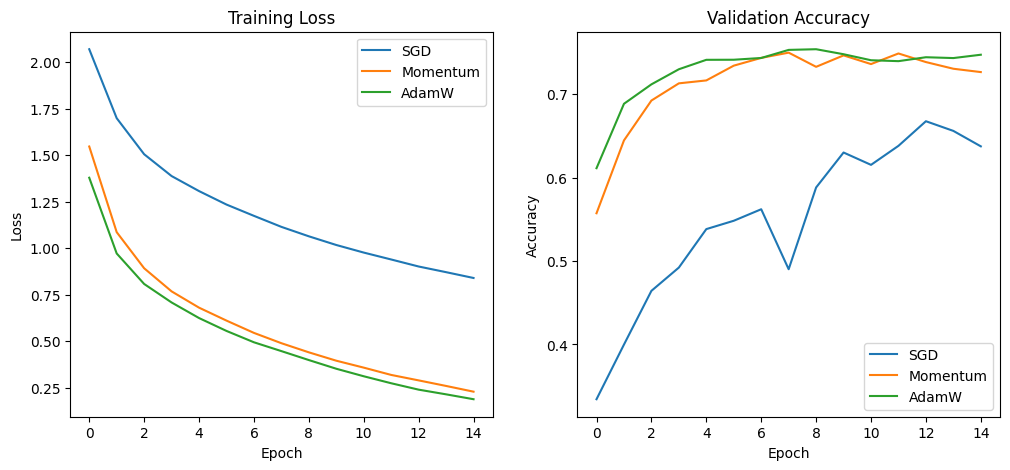

In [7]:
# Plot Training Loss and Validation Accuracy

plt.figure(figsize=(12,5))

# Training Loss
plt.subplot(1,2,1)
plt.plot(sgd_loss, label="SGD")
plt.plot(mom_loss, label="Momentum")
plt.plot(adam_loss, label="AdamW")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Validation Accuracy
plt.subplot(1,2,2)
plt.plot(sgd_acc, label="SGD")
plt.plot(mom_acc, label="Momentum")
plt.plot(adam_acc, label="AdamW")
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

AdamW converges the fastest, showing the lowest training loss within the first few epochs due to its adaptive learning rates, and achieves the highest validation accuracy early on. SGD with momentum significantly improves over vanilla SGD by accelerating convergence and reducing oscillations, reaching competitive accuracy but with slightly more fluctuations. Vanilla SGD converges the slowest, with higher loss and noticeably lower accuracy throughout training. Overall, AdamW provides the best optimization speed, while momentum offers a strong balance between stability and performance compared to standard SGD.

### 1B.2 BatchNorm Ablation

We take the best-performing optimizer from 1B.1, which is AdamW, and train two versions of the same CNN:

- With Batch Normalization after each Conv2D layer (before ReLU)
- Without any normalization

We compare:
- Training loss curves
- Final validation accuracy

In [8]:
# BatchNorm Ablation Experiment Function

def run_bn_experiment(use_bn, optimizer_name="adamw"):
    model = SimpleCNN(use_bn=use_bn).to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "adamw":
        optimizer = optim.AdamW(model.parameters(), lr=0.001)
    elif optimizer_name == "momentum":
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    else:
        optimizer = optim.SGD(model.parameters(), lr=0.01)

    train_losses = []
    val_accuracies = []

    for epoch in range(15):
        loss = train_one_epoch(model, train_loader, optimizer, criterion)
        acc = evaluate(model, val_loader)

        train_losses.append(loss)
        val_accuracies.append(acc)

        print(f"BN={use_bn} | Epoch {epoch+1} | Loss: {loss:.4f} | Acc: {acc:.4f}")

    return train_losses, val_accuracies

In [9]:
# Run BatchNorm vs No BatchNorm
# Using best optimizer from 1B.1 (AdamW)

bn_loss, bn_acc = run_bn_experiment(use_bn=True, optimizer_name="adamw")
nobn_loss, nobn_acc = run_bn_experiment(use_bn=False, optimizer_name="adamw")

BN=True | Epoch 1 | Loss: 1.1558 | Acc: 0.6863
BN=True | Epoch 2 | Loss: 0.8214 | Acc: 0.7198
BN=True | Epoch 3 | Loss: 0.6898 | Acc: 0.7273
BN=True | Epoch 4 | Loss: 0.6101 | Acc: 0.7588
BN=True | Epoch 5 | Loss: 0.5284 | Acc: 0.7642
BN=True | Epoch 6 | Loss: 0.4677 | Acc: 0.7587
BN=True | Epoch 7 | Loss: 0.4040 | Acc: 0.7570
BN=True | Epoch 8 | Loss: 0.3551 | Acc: 0.7669
BN=True | Epoch 9 | Loss: 0.3132 | Acc: 0.7827
BN=True | Epoch 10 | Loss: 0.2709 | Acc: 0.7581
BN=True | Epoch 11 | Loss: 0.2372 | Acc: 0.7706
BN=True | Epoch 12 | Loss: 0.2050 | Acc: 0.7716
BN=True | Epoch 13 | Loss: 0.1814 | Acc: 0.7644
BN=True | Epoch 14 | Loss: 0.1632 | Acc: 0.7800
BN=True | Epoch 15 | Loss: 0.1361 | Acc: 0.7732
BN=False | Epoch 1 | Loss: 1.3605 | Acc: 0.6280
BN=False | Epoch 2 | Loss: 0.9570 | Acc: 0.6787
BN=False | Epoch 3 | Loss: 0.8041 | Acc: 0.7035
BN=False | Epoch 4 | Loss: 0.7042 | Acc: 0.7219
BN=False | Epoch 5 | Loss: 0.6245 | Acc: 0.7432
BN=False | Epoch 6 | Loss: 0.5574 | Acc: 0.7441
B

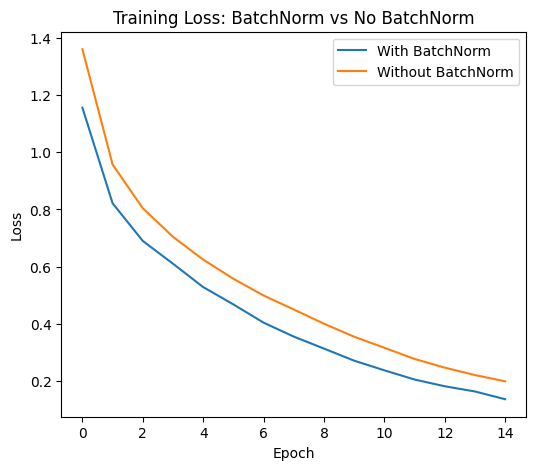

In [10]:
# Plot Training Loss Comparison

plt.figure(figsize=(6,5))

plt.plot(bn_loss, label="With BatchNorm")
plt.plot(nobn_loss, label="Without BatchNorm")

plt.title("Training Loss: BatchNorm vs No BatchNorm")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [11]:
# 1B.2 - Final Validation Accuracy

print("Final Accuracy with BatchNorm:", bn_acc[-1])
print("Final Accuracy without BatchNorm:", nobn_acc[-1])

Final Accuracy with BatchNorm: 0.7732
Final Accuracy without BatchNorm: 0.7438


The model with Batch Normalization converges faster and achieves consistently lower training loss, as BN stabilizes the distribution of activations across layers. This leads to better gradient flow and allows the network to learn more effectively, resulting in higher validation accuracy compared to the model without BN. In contrast, without normalization, internal covariate shift makes training less stable and slows down convergence, leading to a noticeable performance gap.

### 1B.3 Focal Loss

We implement Focal Loss:

$$
FL(p_t) = -\alpha_t (1 - p_t)^\gamma \log(p_t), \quad \gamma = 2.0
$$

We train the BatchNorm-equipped CNN using Focal Loss and compare its validation accuracy with standard Cross-Entropy Loss.

In [12]:
# Focal Loss Implementation

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)  # per-sample loss
        pt = torch.exp(-ce_loss)            # pt = exp(-CE)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

print("Focal Loss ready")

Focal Loss ready


In [13]:
# Train with Cross Entropy Loss

model_ce = SimpleCNN(use_bn=True).to(device)
criterion_ce = nn.CrossEntropyLoss()
optimizer_ce = optim.AdamW(model_ce.parameters(), lr=0.001)

ce_acc = []

for epoch in range(15):
    loss = train_one_epoch(model_ce, train_loader, optimizer_ce, criterion_ce)
    acc = evaluate(model_ce, val_loader)
    
    ce_acc.append(acc)
    
    print(f"CE | Epoch {epoch+1} | Loss: {loss:.4f} | Acc: {acc:.4f}")

CE | Epoch 1 | Loss: 1.1683 | Acc: 0.6699
CE | Epoch 2 | Loss: 0.8264 | Acc: 0.6949
CE | Epoch 3 | Loss: 0.6914 | Acc: 0.7281
CE | Epoch 4 | Loss: 0.6045 | Acc: 0.7376
CE | Epoch 5 | Loss: 0.5328 | Acc: 0.7493
CE | Epoch 6 | Loss: 0.4694 | Acc: 0.7667
CE | Epoch 7 | Loss: 0.4028 | Acc: 0.7666
CE | Epoch 8 | Loss: 0.3582 | Acc: 0.7573
CE | Epoch 9 | Loss: 0.3123 | Acc: 0.7544
CE | Epoch 10 | Loss: 0.2728 | Acc: 0.7727
CE | Epoch 11 | Loss: 0.2346 | Acc: 0.7644
CE | Epoch 12 | Loss: 0.2021 | Acc: 0.7684
CE | Epoch 13 | Loss: 0.1762 | Acc: 0.7727
CE | Epoch 14 | Loss: 0.1595 | Acc: 0.7545
CE | Epoch 15 | Loss: 0.1381 | Acc: 0.7652


In [14]:
# Train with Focal Loss

model_focal = SimpleCNN(use_bn=True).to(device)
criterion_focal = FocalLoss(gamma=2.0)
optimizer_focal = optim.AdamW(model_focal.parameters(), lr=0.001)

focal_acc = []

for epoch in range(15):
    loss = train_one_epoch(model_focal, train_loader, optimizer_focal, criterion_focal)
    acc = evaluate(model_focal, val_loader)
    
    focal_acc.append(acc)
    
    print(f"Focal | Epoch {epoch+1} | Loss: {loss:.4f} | Acc: {acc:.4f}")

Focal | Epoch 1 | Loss: 0.7683 | Acc: 0.6756
Focal | Epoch 2 | Loss: 0.5020 | Acc: 0.7078
Focal | Epoch 3 | Loss: 0.4080 | Acc: 0.7294
Focal | Epoch 4 | Loss: 0.3524 | Acc: 0.7181
Focal | Epoch 5 | Loss: 0.3005 | Acc: 0.7090
Focal | Epoch 6 | Loss: 0.2598 | Acc: 0.7425
Focal | Epoch 7 | Loss: 0.2183 | Acc: 0.7324
Focal | Epoch 8 | Loss: 0.1876 | Acc: 0.7658
Focal | Epoch 9 | Loss: 0.1660 | Acc: 0.7711
Focal | Epoch 10 | Loss: 0.1358 | Acc: 0.7654
Focal | Epoch 11 | Loss: 0.1140 | Acc: 0.7648
Focal | Epoch 12 | Loss: 0.1055 | Acc: 0.7597
Focal | Epoch 13 | Loss: 0.0862 | Acc: 0.7537
Focal | Epoch 14 | Loss: 0.0791 | Acc: 0.7530
Focal | Epoch 15 | Loss: 0.0687 | Acc: 0.7477


In [15]:
# Compare Final Validation Accuracy

print("Final Accuracy (Cross Entropy):", ce_acc[-1])
print("Final Accuracy (Focal Loss):", focal_acc[-1])

Final Accuracy (Cross Entropy): 0.7652
Final Accuracy (Focal Loss): 0.7477


Focal Loss does not provide an advantage in this setting, as Cross-Entropy achieves higher final validation accuracy. This is expected since CIFAR-10 is a balanced dataset, whereas Focal Loss is primarily beneficial in scenarios with significant class imbalance by focusing more on hard examples.

### 1B.4 Gradient Accumulation in PyTorch 

We simulate a larger effective batch size using gradient accumulation.

- DataLoader batch size = 8
- Accumulate gradients over 4 steps
- Effective batch size = 32

We perform multiple forward-backward passes before calling optimizer.step(), and print the loss for the first 50 optimizer steps to verify that training is progressing.

In [16]:
# DataLoader with Small Batch Size (8)

train_loader_small = torch.utils.data.DataLoader(
    train_dataset, batch_size=8, shuffle=True
)

In [ ]:
# Gradient Accumulation Training Loop

model_accum = SimpleCNN(use_bn=True).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_accum.parameters(), lr=0.001)

accum_steps = 4  # 8 x 4 = 32 effective batch
optimizer_steps = 0

model_accum.train()

for epoch in range(1):  # 1 epoch is enough for demonstration
    optimizer.zero_grad()

    for i, (images, labels) in enumerate(train_loader_small):
        images, labels = images.to(device), labels.to(device)

        outputs = model_accum(images)
        loss = criterion(outputs, labels)

        # SCALE LOSS
        loss = loss / accum_steps

        loss.backward()

        # Perform optimizer step after accum_steps
        if (i + 1) % accum_steps == 0:
            optimizer.step()
            optimizer.zero_grad()

            optimizer_steps += 1

            # Print first 50 optimizer steps
            if optimizer_steps <= 50:
                print(f"Step {optimizer_steps} | Loss: {loss.item():.4f}")

        if optimizer_steps >= 50:
            break

    if optimizer_steps >= 50:
        break

Step 1 | Loss: 0.6467
Step 2 | Loss: 0.8023
Step 3 | Loss: 0.5934
Step 4 | Loss: 0.4560
Step 5 | Loss: 0.5305
Step 6 | Loss: 0.4845
Step 7 | Loss: 0.5532
Step 8 | Loss: 0.5932
Step 9 | Loss: 0.5021
Step 10 | Loss: 0.5162
Step 11 | Loss: 0.4137
Step 12 | Loss: 0.5650
Step 13 | Loss: 0.5443
Step 14 | Loss: 0.4339
Step 15 | Loss: 0.6234
Step 16 | Loss: 0.5526
Step 17 | Loss: 0.4633
Step 18 | Loss: 0.4280
Step 19 | Loss: 0.4239
Step 20 | Loss: 0.6467
Step 21 | Loss: 0.4726
Step 22 | Loss: 0.4376
Step 23 | Loss: 0.5229
Step 24 | Loss: 0.4986
Step 25 | Loss: 0.5788
Step 26 | Loss: 0.4195
Step 27 | Loss: 0.3535
Step 28 | Loss: 0.3988
Step 29 | Loss: 0.5724
Step 30 | Loss: 0.4057
Step 31 | Loss: 0.6221
Step 32 | Loss: 0.3554
Step 33 | Loss: 0.6028
Step 34 | Loss: 0.4156
Step 35 | Loss: 0.3380
Step 36 | Loss: 0.4027
Step 37 | Loss: 0.3596
Step 38 | Loss: 0.4907
Step 39 | Loss: 0.4957
Step 40 | Loss: 0.6547
Step 41 | Loss: 0.4983
Step 42 | Loss: 0.3884
Step 43 | Loss: 0.4019
Step 44 | Loss: 0.35

The printed losses show an overall decreasing trend across optimizer steps, although with some fluctuations due to mini-batch variability. This indicates that gradient accumulation is working correctly and the model is learning effectively. Despite using smaller batches, the accumulated gradients successfully simulate a larger batch size, leading to stable training behavior.